# Ch8 前饋(Feed-Forward)

**對應原書**:Chapter 8
**軟體替代**:ModelQ 前饋路徑方塊 → 串級迴路逐樣本模擬 + 梯形速度規劃

## 學習目標
1. 理解回授的天生限制:**誤差要先出現,控制器才會動作**。
2. 實作速度前饋(velocity FF)與加速度前饋(acceleration FF)。
3. 量化前饋對**追隨誤差(following error)**的改善。

## 結構
```
pos_ref ──►(+)──kp_p──►(+)──► [PI 速度迴路] ──►(+)──► 1/(Js+b) ──► w ──∫──► pos
            ▲-          ▲                      ▲
           pos      Kvff·vel_ref          Kaff·J·acc_ref
```
前饋直接把「已知的命令軌跡」轉成速度/轉矩需求,回授只需要處理誤差與擾動。

In [1]:
import sys, pathlib
sys.path.append(str(pathlib.Path('..').resolve()))
import numpy as np
import matplotlib.pyplot as plt
import control as ct
from common.control_helpers import (first_order, second_order, integrator, inertia,
                                    pi, pid, closed_loop, margins, step_metrics, bandwidth_hz)
from common.sim import (DiscretePID, MotorPlant, DCMotorPlant, TwoMassPlant,
                        Backlash, EncoderModel, Delay, saturate, quantize, coulomb)
from common.dsa import chirp_excitation, prbs_excitation, measure_frf, frf_of_system
from common.plots import bode_compare
np.set_printoptions(precision=4, suppress=True)

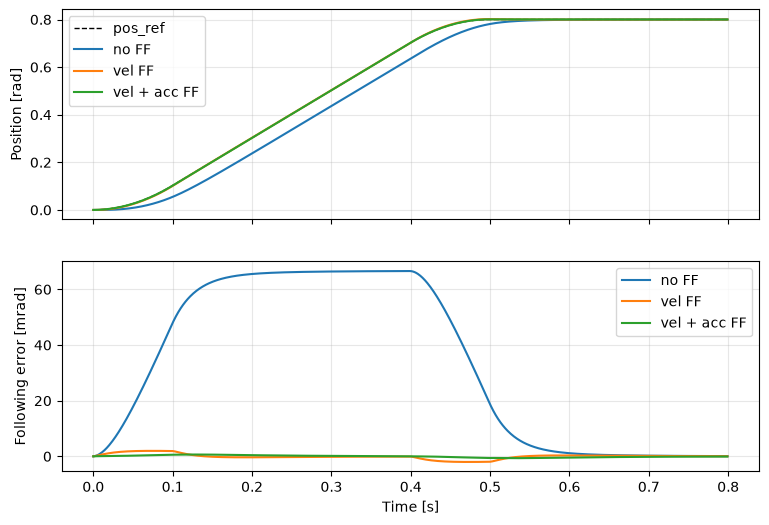

峰值追隨誤差 [mrad]: {'no FF': 66.58, 'vel FF': 2.01, 'vel + acc FF': 0.67}


In [2]:
J, b = 0.002, 0.01
fs = 1000.0
dt = 1 / fs

# --- 梯形速度規劃:加速 0.1 s、等速 0.3 s、減速 0.1 s ---
acc_max, t_acc, t_cruise = 20.0, 0.1, 0.3
n = int(0.8 / dt)
t = np.arange(n) * dt
acc_ref = np.zeros(n)
acc_ref[t < t_acc] = acc_max
acc_ref[(t >= t_acc + t_cruise) & (t < 2 * t_acc + t_cruise)] = -acc_max
vel_ref = np.cumsum(acc_ref) * dt
pos_ref = np.cumsum(vel_ref) * dt

def run(kvff=0.0, kaff=0.0, kp_pos=30.0):
    plant = MotorPlant(J=J, b=b, dt=dt)
    vel_pi = DiscretePID(kp=0.5, ki=5.0, dt=dt)
    pos, err = np.empty(n), np.empty(n)
    for k in range(n):
        pos[k] = plant.pos
        err[k] = pos_ref[k] - plant.pos
        v_cmd = kp_pos * err[k] + kvff * vel_ref[k]
        u = vel_pi.step(v_cmd - plant.w) + kaff * J * acc_ref[k]
        plant.step(u)
    return pos, err

cases = {'no FF': (0.0, 0.0), 'vel FF': (1.0, 0.0), 'vel + acc FF': (1.0, 1.0)}
errs = {}
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
ax1.plot(t, pos_ref, 'k--', lw=1, label='pos_ref')
for name, (kv, ka) in cases.items():
    pos, err = run(kv, ka)
    errs[name] = err
    ax1.plot(t, pos, label=name)
    ax2.plot(t, err * 1000, label=name)
ax1.set_ylabel('Position [rad]'); ax1.legend(); ax1.grid(alpha=0.3)
ax2.set_ylabel('Following error [mrad]'); ax2.set_xlabel('Time [s]')
ax2.legend(); ax2.grid(alpha=0.3)
plt.show()

peak = {name: float(np.max(np.abs(e))) for name, e in errs.items()}
print('峰值追隨誤差 [mrad]:', {k: round(v * 1000, 2) for k, v in peak.items()})

## 前饋比例掃描

實務上 100% 速度前饋常帶來 overshoot(前饋直接命令、回授又補一次),
Ellis 建議依機台特性取 50~100% 之間。掃描看取捨。

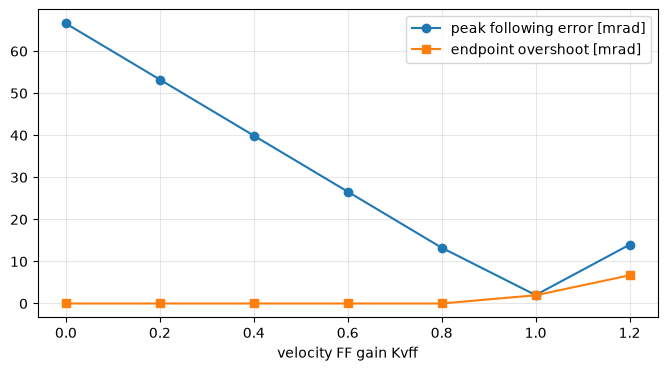

{0.0: 66.58, 0.2: 53.25, 0.4: 39.92, 0.6: 26.59, 0.8: 13.27, 1.0: 2.01, 1.2: 13.97}


In [3]:
kvs = np.arange(0.0, 1.21, 0.2)
peaks_kv, os_kv = [], []
for kv in kvs:
    pos, err = run(kvff=float(kv), kaff=0.0)
    peaks_kv.append(np.max(np.abs(err)))
    os_kv.append(max(0.0, float(pos.max() - pos_ref.max())))
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(kvs, np.array(peaks_kv) * 1000, 'o-', label='peak following error [mrad]')
ax1.plot(kvs, np.array(os_kv) * 1000, 's-', label='endpoint overshoot [mrad]')
ax1.set_xlabel('velocity FF gain Kvff'); ax1.legend(); ax1.grid(alpha=0.3)
plt.show()
print(dict(zip(np.round(kvs, 1).tolist(), np.round(np.array(peaks_kv) * 1000, 2).tolist())))

In [4]:
# ✅ 驗證
assert peak['no FF'] > peak['vel FF'] > peak['vel + acc FF']
assert peak['vel FF'] < 0.25 * peak['no FF']          # 速度前饋至少改善 4 倍
assert peak['vel + acc FF'] < 0.5 * peak['vel FF']    # 加速度前饋再改善
# 無前饋時,等速段誤差 ≈ v / kp_pos
cruise = (t > t_acc + 0.05) & (t < t_acc + t_cruise - 0.05)
e_cruise = float(np.mean(errs['no FF'][cruise]))
assert abs(e_cruise - vel_ref.max() / 30.0) / (vel_ref.max() / 30.0) < 0.15
print('Ch8 驗證通過 ✅')

Ch8 驗證通過 ✅


## 練習
1. 把 `kp_pos` 加倍,無前饋的追隨誤差怎麼變?這條路的代價是什麼(想想第 4、16 章)?
2. 對 vel_ref 加一階低通(時間常數 2 ms)再前饋,端點 overshoot 有無改善?
3. 受控體慣量誤差 +30% 時,acc FF 的效益剩多少?
4. 實作 S 曲線(jerk 受限)規劃,比較梯形與 S 曲線的峰值誤差。